# 第 11 章 · 冰湖导航价值迭代代码实验

本页把冰湖导航看成一个 MDP：每个格子是状态，每个方向是动作。先用确定版地图观察起点选择、下一步状态和价值如何从终点向外传播。

[章节网页](../ch11.html)

## 运行内容

- 查看起点与下一步
- 执行价值迭代
- 绘制价值与策略

## 0. 冰湖环境

先看地图、转移表和起点动作。S 是起点，F 是安全冰面，H 是洞，G 是终点；确定版地图能先把状态转移看清楚。

In [1]:
# 载入本页会用到的数据集、模型和绘图工具。
import importlib.util
import contextlib
import io
import logging
import math
import os
import subprocess
import sys
import warnings
from collections import Counter, defaultdict
from pathlib import Path

required_packages = {
    "numpy": "numpy>=1.24",
    "pandas": "pandas>=2.0",
    "matplotlib": "matplotlib>=3.7",
    "scipy": "scipy>=1.10",
    "sklearn": "scikit-learn>=1.3",
}
missing = [package for module, package in required_packages.items() if importlib.util.find_spec(module) is None]

os.environ.setdefault("HF_HUB_DISABLE_PROGRESS_BARS", "1")
os.environ.setdefault("TRANSFORMERS_VERBOSITY", "error")
os.environ.setdefault("DIFFUSERS_VERBOSITY", "error")

def install_packages(packages):
    if not packages:
        return
    command = [sys.executable, "-m", "pip", "install", "--quiet", "--disable-pip-version-check", *packages]
    try:
        subprocess.check_call(command, stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
    except subprocess.CalledProcessError as exc:
        raise RuntimeError("依赖安装失败，请检查网络后重新运行本单元。") from exc

install_packages(missing)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from PIL import Image
from IPython.display import display
from scipy.signal import correlate2d
from sklearn.datasets import load_breast_cancer, load_digits, load_iris, load_sample_image, make_moons
from sklearn.decomposition import TruncatedSVD
from sklearn.linear_model import Ridge
from sklearn.metrics import accuracy_score, confusion_matrix, log_loss, mean_squared_error
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.neural_network import MLPClassifier, MLPRegressor
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler, normalize
from sklearn.svm import SVC

font_paths = [
    "/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc",
    "/usr/share/fonts/opentype/noto/NotoSansCJK-Bold.ttc",
    "/System/Library/Fonts/Supplemental/Arial Unicode.ttf",
    "/Library/Fonts/Arial Unicode.ttf",
    "/System/Library/Fonts/STHeiti Medium.ttc",
    "/System/Library/Fonts/STHeiti Light.ttc",
]
font_name = "DejaVu Sans"
for path in font_paths:
    if Path(path).exists():
        fm.fontManager.addfont(path)
        font_name = fm.FontProperties(fname=path).get_name()
        break

logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)
logging.getLogger("transformers").setLevel(logging.ERROR)
logging.getLogger("diffusers").setLevel(logging.ERROR)
logging.getLogger("huggingface_hub").setLevel(logging.ERROR)
warnings.filterwarnings("ignore")
plt.rcParams.update({
    "figure.dpi": 110,
    "axes.unicode_minus": False,
    "font.family": "sans-serif",
    "font.sans-serif": [font_name, "DejaVu Sans", "sans-serif"],
})

In [2]:
# 载入强化学习经典环境。
if importlib.util.find_spec("gymnasium") is None:
    install_packages(["gymnasium>=0.29"])

import gymnasium as gym

In [3]:
# 冰湖导航：先用确定版地图学习状态、动作、转移和价值。
frozen_env = gym.make("FrozenLake-v1", map_name="4x4", is_slippery=False)
n_states = frozen_env.observation_space.n
n_actions = frozen_env.action_space.n
action_names = {0: "左", 1: "下", 2: "右", 3: "上"}
action_arrows = {0: "←", 1: "↓", 2: "→", 3: "↑"}
lake_map = np.array([
    [cell.decode("utf-8") if isinstance(cell, bytes) else str(cell) for cell in row]
    for row in frozen_env.unwrapped.desc
])

transition_rows = []
for state in range(n_states):
    row, col = divmod(state, 4)
    tile = lake_map[row, col]
    for action, outcomes in frozen_env.unwrapped.P[state].items():
        for prob, next_state, reward, terminated in outcomes:
            transition_rows.append({
                "状态": state,
                "格子": tile,
                "动作": action_names[action],
                "概率": prob,
                "下一状态": next_state,
                "奖励": reward,
                "是否结束": terminated,
            })

display(pd.DataFrame(transition_rows).head(16))
display(pd.DataFrame(lake_map))

,状态,格子,动作,概率,下一状态,奖励,是否结束
0,0,S,左,1.0,0,0.0,False
1,0,S,下,1.0,4,0.0,False
2,0,S,右,1.0,1,0.0,False
3,0,S,上,1.0,0,0.0,False
4,1,F,左,1.0,0,0.0,False
5,1,F,下,1.0,5,0.0,True
6,1,F,右,1.0,2,0.0,False
7,1,F,上,1.0,1,0.0,False
8,2,F,左,1.0,1,0.0,False
9,2,F,下,1.0,6,0.0,False


,0,1,2,3
0,S,F,F,F
1,F,H,F,H
2,F,F,F,H
3,H,F,F,G


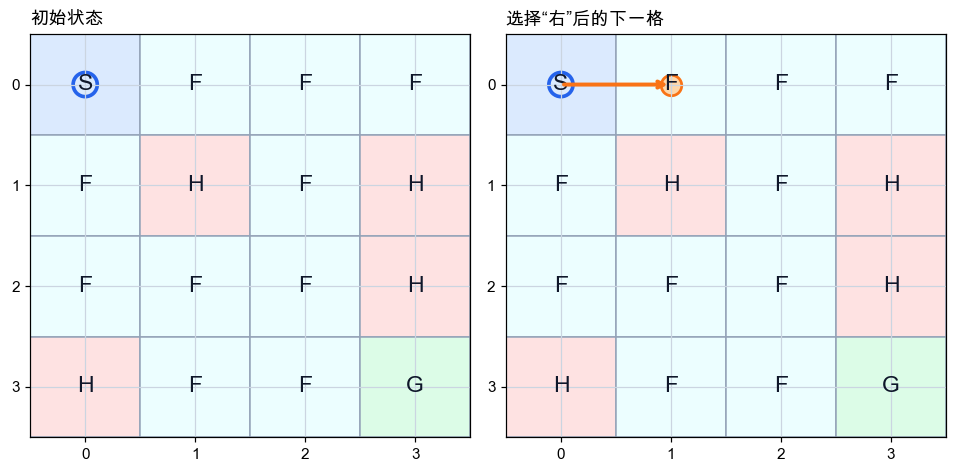

,当前格,选择动作,可能到达,概率,奖励,是否结束
0,"S(0,0)",左,"S(0,0)",1.0,0.0,False
1,"S(0,0)",下,"F(1,0)",1.0,0.0,False
2,"S(0,0)",右,"F(0,1)",1.0,0.0,False
3,"S(0,0)",上,"S(0,0)",1.0,0.0,False


In [4]:
# 从起点看一次决策：先选择动作，再进入下一格。
start_state = 0
start_row, start_col = divmod(start_state, 4)
start_options = []
for action, outcomes in frozen_env.unwrapped.P[start_state].items():
    for prob, next_state, reward, terminated in outcomes:
        next_row, next_col = divmod(next_state, 4)
        start_options.append({
            "当前格": f"S({start_row},{start_col})",
            "选择动作": action_names[action],
            "可能到达": f"{lake_map[next_row, next_col]}({next_row},{next_col})",
            "概率": prob,
            "奖励": reward,
            "是否结束": terminated,
        })

tile_color = {"S": "#dbeafe", "F": "#ecfeff", "H": "#fee2e2", "G": "#dcfce7"}
def draw_lake_state(ax, highlight_state, title, arrow_to=None):
    for r in range(4):
        for c in range(4):
            tile = lake_map[r, c]
            ax.add_patch(plt.Rectangle((c - 0.5, r - 0.5), 1, 1, color=tile_color[tile], ec="#94a3b8"))
            ax.text(c, r, tile, ha="center", va="center", fontsize=15, fontweight="bold", color="#0f172a")
    hr, hc = divmod(highlight_state, 4)
    ax.scatter([hc], [hr], s=250, facecolors="none", edgecolors="#2563eb", linewidths=2.4)
    if arrow_to is not None:
        nr, nc = divmod(arrow_to, 4)
        ax.annotate("", xy=(nc, nr), xytext=(hc, hr), arrowprops={"arrowstyle": "->", "lw": 2.6, "color": "#f97316"})
        ax.scatter([nc], [nr], s=180, color="#fed7aa", edgecolors="#f97316", linewidths=1.8)
    ax.set_title(title, loc="left", fontweight="bold")
    ax.set_xlim(-0.5, 3.5)
    ax.set_ylim(3.5, -0.5)
    ax.set_xticks(range(4))
    ax.set_yticks(range(4))
    ax.grid(True, color="#cbd5e1", linewidth=0.8)

first_action = 2
first_next_state = frozen_env.unwrapped.P[start_state][first_action][0][1]
fig, axes = plt.subplots(1, 2, figsize=(8.8, 4.4))
draw_lake_state(axes[0], start_state, "初始状态")
draw_lake_state(axes[1], start_state, f"选择“{action_names[first_action]}”后的下一格", first_next_state)
plt.tight_layout()
plt.show()

display(pd.DataFrame(start_options).round(3))

## 1. 价值迭代

先看一个状态的一次 Bellman 更新，再运行完整迭代。误差曲线下降后，策略箭头就代表当前最推荐的动作。

In [5]:
# 看一次 Bellman 更新：靠近终点的状态，会把“可能到达 G 的奖励”传给动作价值。
focus_state = 14
focus_row, focus_col = divmod(focus_state, 4)
old_V = np.zeros(n_states)
one_step_rows = []
for action, outcomes in frozen_env.unwrapped.P[focus_state].items():
    q_value = 0.0
    destinations = []
    for prob, next_state, reward, terminated in outcomes:
        next_row, next_col = divmod(next_state, 4)
        contribution = prob * (reward + 0.99 * old_V[next_state] * (not terminated))
        q_value += contribution
        destinations.append(f"{prob:.2f}→{lake_map[next_row, next_col]}({next_row},{next_col})")
    one_step_rows.append({
        "状态": f"{lake_map[focus_row, focus_col]}({focus_row},{focus_col})",
        "动作": action_names[action],
        "可能转移": " / ".join(destinations),
        "本轮 Q(s,a)": q_value,
    })

display(pd.DataFrame(one_step_rows).round(4))

,状态,动作,可能转移,"本轮 Q(s,a)"
0,"F(3,2)",左,"1.00→F(3,1)",0.0
1,"F(3,2)",下,"1.00→F(3,2)",0.0
2,"F(3,2)",右,"1.00→G(3,3)",1.0
3,"F(3,2)",上,"1.00→F(2,2)",0.0


In [6]:
# 价值迭代：对 FrozenLake 的 P 表应用 Bellman 最优方程。
def frozenlake_value_iteration(env, gamma=0.99, theta=1e-9, max_iters=1000):
    V = np.zeros(env.observation_space.n)
    deltas = []

    for iteration in range(1, max_iters + 1):
        old_V = V.copy()
        for state in range(env.observation_space.n):
            action_values = []
            for action in range(env.action_space.n):
                q = 0.0
                for prob, next_state, reward, terminated in env.unwrapped.P[state][action]:
                    q += prob * (reward + gamma * old_V[next_state] * (not terminated))
                action_values.append(q)
            V[state] = max(action_values)
        delta = float(np.max(np.abs(V - old_V)))
        deltas.append({"iteration": iteration, "delta": delta})
        if delta < theta:
            break

    Q = np.zeros((env.observation_space.n, env.action_space.n))
    for state in range(env.observation_space.n):
        for action in range(env.action_space.n):
            Q[state, action] = sum(
                prob * (reward + gamma * V[next_state] * (not terminated))
                for prob, next_state, reward, terminated in env.unwrapped.P[state][action]
            )

    action_priority = [2, 1, 3, 0]
    policy = np.zeros(env.observation_space.n, dtype=int)
    for state in range(env.observation_space.n):
        best_actions = np.flatnonzero(np.isclose(Q[state], Q[state].max()))
        for candidate in action_priority:
            if candidate in best_actions:
                policy[state] = candidate
                break
    return V, Q, policy, pd.DataFrame(deltas)


V_frozen, Q_frozen, policy_frozen, delta_trace = frozenlake_value_iteration(frozen_env)
policy_df = pd.DataFrame({
    "状态": np.arange(n_states),
    "格子": lake_map.reshape(-1),
    "推荐动作": [action_names[a] for a in policy_frozen],
    "V": V_frozen,
    "Q_左": Q_frozen[:, 0],
    "Q_下": Q_frozen[:, 1],
    "Q_右": Q_frozen[:, 2],
    "Q_上": Q_frozen[:, 3],
}).round(4)

display(delta_trace.head(8).rename(columns={"iteration": "迭代轮次", "delta": "最大价值变化"}))
display(delta_trace.tail(5).rename(columns={"iteration": "迭代轮次", "delta": "最大价值变化"}))
display(policy_df)

,迭代轮次,最大价值变化
0,1,1.000000
1,2,0.990000
2,3,0.980100
3,4,0.970299
4,5,0.960596
5,6,0.950990
6,7,0.000000


,迭代轮次,最大价值变化
2,3,0.980100
3,4,0.970299
4,5,0.960596
5,6,0.950990
6,7,0.000000


,状态,格子,推荐动作,V,Q_左,Q_下,Q_右,Q_上
0,0,S,右,0.9510,0.9415,0.9510,0.9510,0.9415
1,1,F,右,0.9606,0.9415,0.0000,0.9606,0.9510
2,2,F,下,0.9703,0.9510,0.9703,0.9510,0.9606
3,3,F,左,0.9606,0.9606,0.0000,0.9510,0.9510
4,4,F,下,0.9606,0.9510,0.9606,0.0000,0.9415
5,5,H,右,0.0000,0.0000,0.0000,0.0000,0.0000
6,6,F,下,0.9801,0.0000,0.9801,0.0000,0.9606
7,7,H,右,0.0000,0.0000,0.0000,0.0000,0.0000
8,8,F,右,0.9703,0.9606,0.0000,0.9703,0.9510
9,9,F,右,0.9801,0.9606,0.9801,0.9801,0.0000


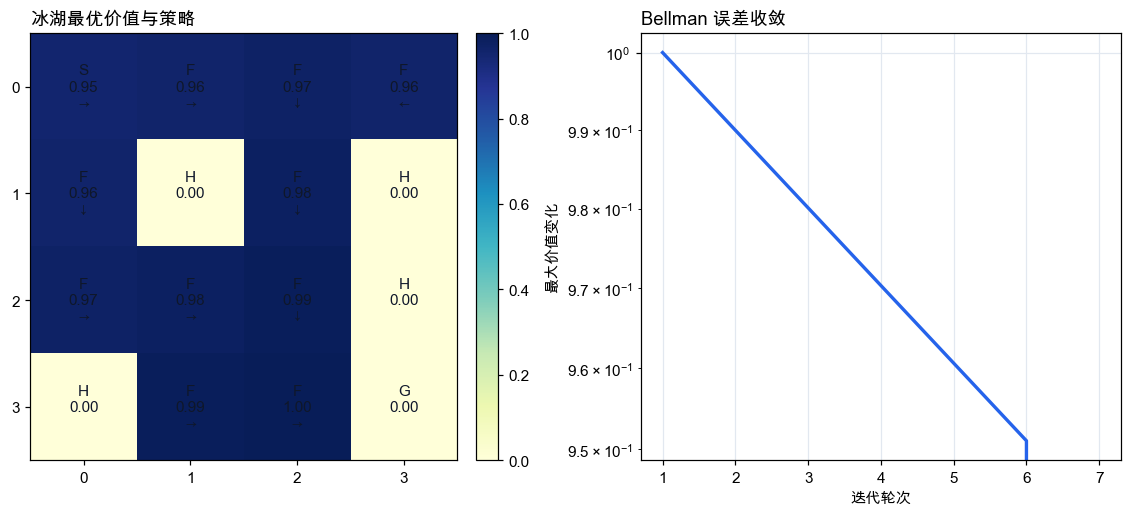

In [7]:
# 绘制 FrozenLake 的价值、洞、终点和最优动作。
value_grid = V_frozen.reshape(4, 4)
fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.8))
im = axes[0].imshow(value_grid, cmap="YlGnBu", vmin=0, vmax=value_grid.max())
for state in range(n_states):
    r, c = divmod(state, 4)
    tile = lake_map[r, c]
    arrow = "" if tile in {"H", "G"} else action_arrows[int(policy_frozen[state])]
    axes[0].text(c, r, f"{tile}\n{value_grid[r, c]:.2f}\n{arrow}", ha="center", va="center", color="#0f172a", fontweight="bold")
axes[0].set_title("冰湖最优价值与策略", loc="left", fontweight="bold")
axes[0].set_xticks(range(4))
axes[0].set_yticks(range(4))
fig.colorbar(im, ax=axes[0], fraction=0.046, pad=0.04)

axes[1].plot(delta_trace["iteration"], delta_trace["delta"], color="#2563eb", linewidth=2.2)
axes[1].set_yscale("log")
axes[1].set_title("Bellman 误差收敛", loc="left", fontweight="bold")
axes[1].set_xlabel("迭代轮次")
axes[1].set_ylabel("最大价值变化")
axes[1].grid(True, color="#e2e8f0", linewidth=0.8)
plt.tight_layout()
plt.show()